<a href="https://colab.research.google.com/github/KaterinaSor2005/homework_Sorokina332/blob/main/hw4(pandas).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("flights.csv", low_memory=False)
airlines = pd.read_csv("airlines.csv")
airports = pd.read_csv("airports.csv")

# 1. Час вылета
Больше всего рейсов вылетает утром и днём. Чем ближе к вечеру, тем дольше задержки. Это похоже на эффект домино: один опоздавший рейс задерживает следующие. Самые большие опоздания — в 6–8 вечера.

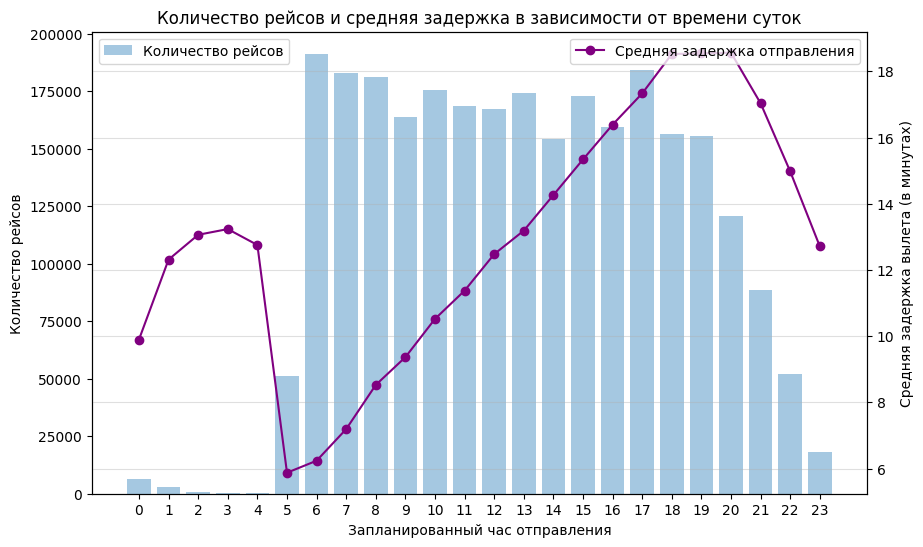

In [24]:
# час вылета
df["DEPARTURE_HOUR"] = df["SCHEDULED_DEPARTURE"] // 100

# неотменённые рейсы
df_delays = df[df["CANCELLED"] == 0].copy()
df_delays["DEPARTURE_DELAY_POSITIVE"] = df_delays["DEPARTURE_DELAY"].clip(lower=0)

# Группируем по часу
hour_delay = df_delays.groupby("DEPARTURE_HOUR")["DEPARTURE_DELAY_POSITIVE"].mean()
hour_flights = df_delays.groupby("DEPARTURE_HOUR").size()

hour_delay = hour_delay.sort_index()
hour_flights = hour_flights.sort_index()

# график
fig, ax1 = plt.subplots(figsize=(10,6))
bars = ax1.bar(hour_flights.index, hour_flights.values, alpha=0.4, label="Количество рейсов")
ax1.set_xlabel("Запланированный час отправления")
ax1.set_ylabel("Количество рейсов")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
line, = ax2.plot(hour_delay.index, hour_delay.values, color="purple", marker="o", label="Средняя задержка отправления")
ax2.set_ylabel("Средняя задержка вылета (в минутах)")

plt.grid(True, alpha=0.4)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Количество рейсов и средняя задержка в зависимости от времени суток")
plt.show()

# 2. День недели
В понедельник и вторник рейсы задерживают чаще всего. В выходные, особенно в субботу, летает меньше самолётов, и опаздывают они реже. Похоже, что после выходных аэропорты и авиакомпании не успевают справляться с нагрузкой.

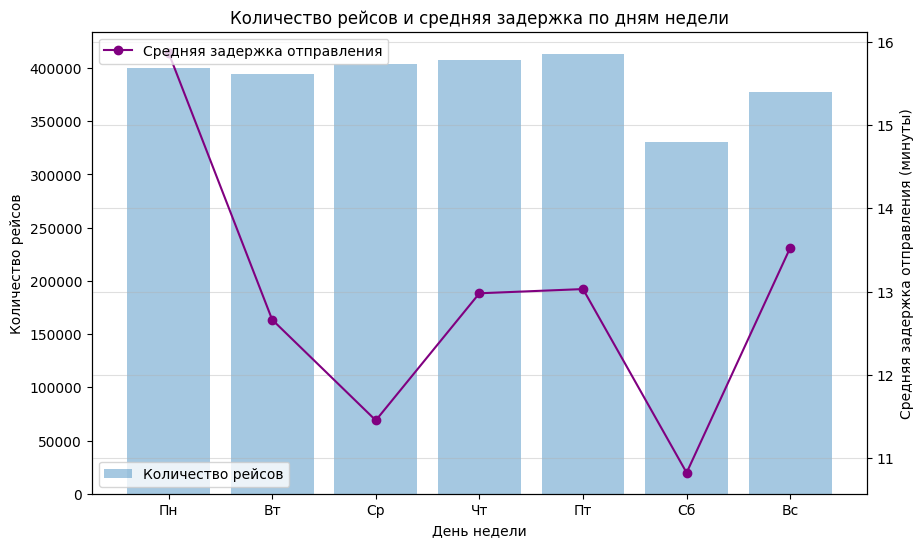

In [23]:
weekday_delay = df_delays.groupby("DAY_OF_WEEK")["DEPARTURE_DELAY_POSITIVE"].mean()
weekday_flights = df_delays.groupby("DAY_OF_WEEK").size()

weekday_delay = weekday_delay.sort_index()
weekday_flights = weekday_flights.sort_index()

fig, ax1 = plt.subplots(figsize=(10,6))
bars = ax1.bar(weekday_flights.index, weekday_flights.values, alpha=0.4, label="Количество рейсов")
ax1.set_xlabel("День недели")
ax1.set_ylabel("Количество рейсов")
ax1.set_xticks(range(1,8))
ax1.set_xticklabels(["Пн","Вт","Ср","Чт","Пт","Сб","Вс"])

ax2 = ax1.twinx()
line, = ax2.plot(weekday_delay.index, weekday_delay.values, color="purple", marker="o", label="Средняя задержка отправления")
ax2.set_ylabel("Средняя задержка отправления (минуты)")

plt.grid(True, alpha=0.4)
ax1.legend(loc="lower left")
ax2.legend(loc="upper left")
plt.title("Количество рейсов и средняя задержка по дням недели")
plt.show()

# 3. Месяц
Количество рейсов в течение года почти не меняется, а вот задержки становятся больше летом и в декабре. Летом — потому что много народу летит в отпуск, в декабре — из-за праздников и плохой погоды.

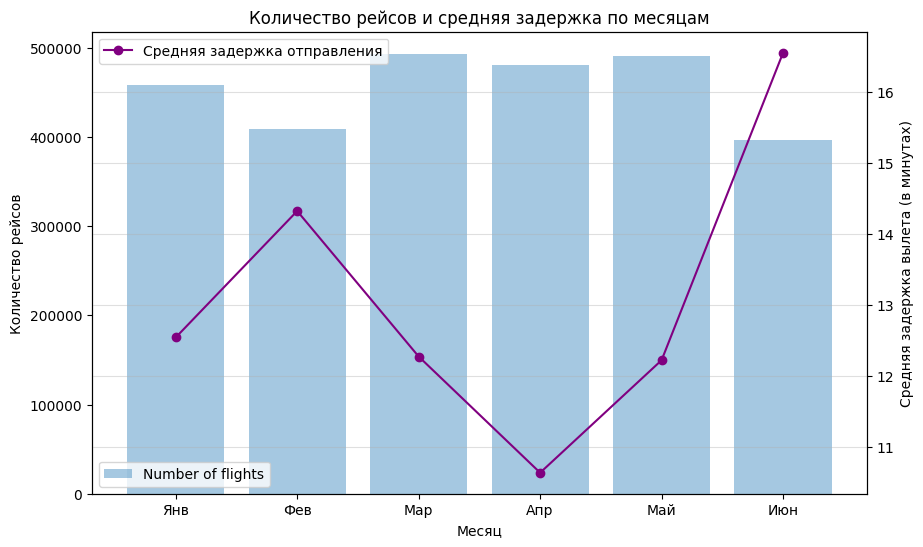

In [22]:
month_delay = df_delays.groupby("MONTH")["DEPARTURE_DELAY_POSITIVE"].mean()
month_flights = df_delays.groupby("MONTH").size()

month_delay = month_delay.sort_index()
month_flights = month_flights.sort_index()

fig, ax1 = plt.subplots(figsize=(10,6))
bars = ax1.bar(month_flights.index, month_flights.values, alpha=0.4, label="Number of flights")
ax1.set_xlabel("Месяц")
ax1.set_ylabel("Количество рейсов")
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(["Янв","Фев","Мар","Апр","Май","Июн","Июл","Авг","Сен","Окт","Ноя","Дек"])

ax2 = ax1.twinx()
line, = ax2.plot(month_delay.index, month_delay.values, color="purple", marker="o", label="Средняя задержка отправления")
ax2.set_ylabel("Средняя задержка вылета (в минутах)")

plt.grid(True, alpha=0.4)
ax1.legend(loc="lower left")
ax2.legend(loc="upper left")
plt.title("Количество рейсов и средняя задержка по месяцам")
plt.show()

# 4. Причины отмен рейсов
Больше половины всех отмен — из‑за погоды. На втором месте — проблемы самих авиакомпаний, на третьем — сбои в работе авиационной системы. Погоду не изменить, но внутренние проблемы можно уменьшить, если лучше планировать.

CANCELLATION_REASON
Погода               36960
Аэропорты            14987
Воздушная система     9874
Security                 8
Name: count, dtype: int64


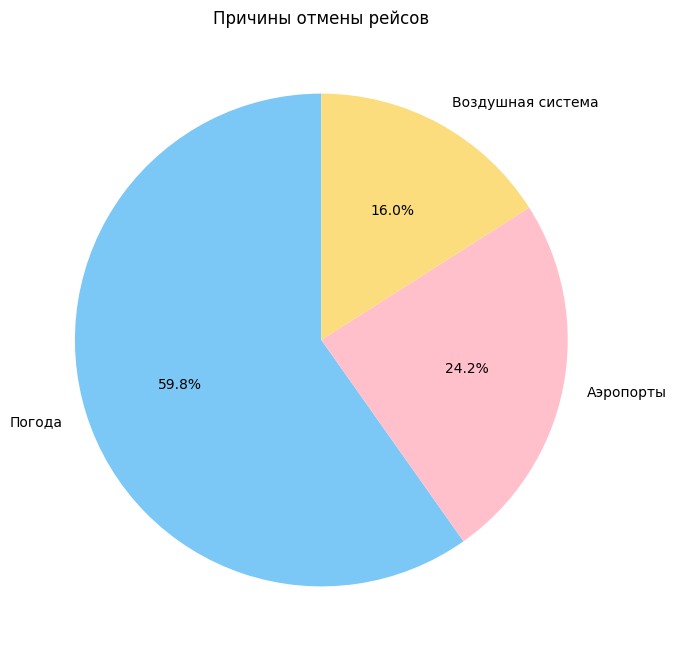

In [21]:
df_cancelled = df[df["CANCELLED"] == 1].copy()

reason_labels = {"A": "Аэропорты", "B": "Погода", "C": "Воздушная система", "D": "Security"}
cancel_reasons = df_cancelled["CANCELLATION_REASON"].value_counts()
cancel_reasons.index = cancel_reasons.index.map(reason_labels)

print(cancel_reasons)

cancel_reasons = cancel_reasons.drop("Security", errors="ignore")

plt.figure(figsize=(8,8))
plt.pie(cancel_reasons.values, labels=cancel_reasons.index,
        autopct="%1.1f%%", startangle=90,
        colors=["#7BC8F6", "#FFC0CB", "#FBDD7E"])
plt.title("Причины отмены рейсов")
plt.show()

# 5. Аэропорты, где чаще всего задерживают рейсы
Больше всего задержек в аэропортах Гуам, Адак и Густавус — там опаздывает больше 65% рейсов. Это небольшие и удалённые аэропорты, где любой сбой сразу заметен. Но и в крупных аэропортах, например в Ньюарке, тоже много задержек — там просто слишком много рейсов.

# 6. Почему задерживают рейсы в проблемных аэропортах
Главная причина — самолёт прилетает позже, чем нужно (эффект цепочки). На втором месте — проблемы самой авиакомпании. Погода и сбои в системе влияют гораздо меньше. Чтобы стало лучше, надо налаживать работу авиакомпаний и делать так, чтобы опоздания не копились.

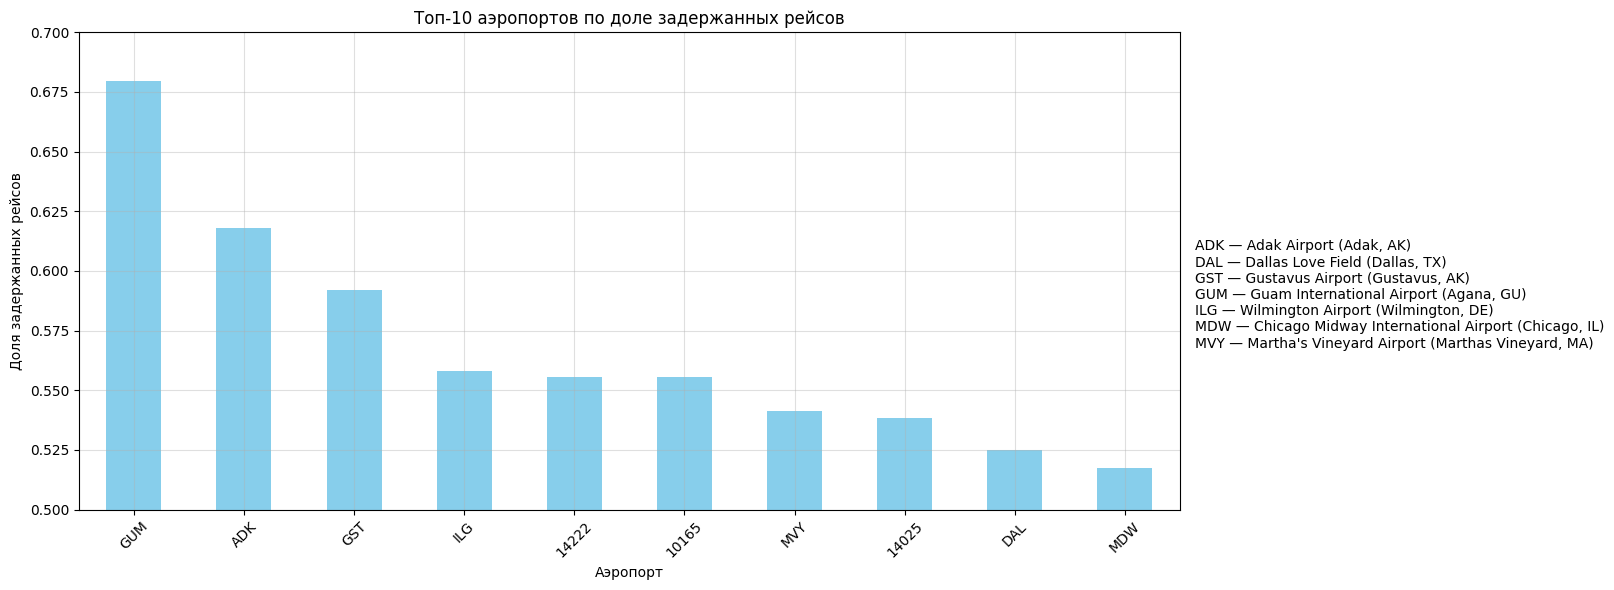

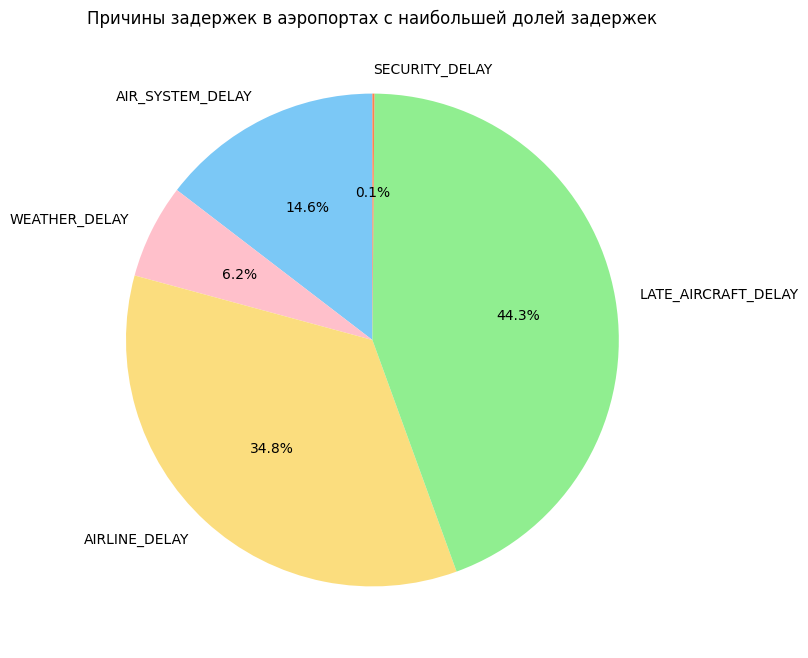

In [29]:
df_not_cancelled = df[(df["CANCELLED"] == 0) & (df["DEPARTURE_DELAY"].notna())].copy()
df_not_cancelled["IS_DELAYED"] = (df_not_cancelled["DEPARTURE_DELAY"] > 0).astype(int)

airport_delay_share = df_not_cancelled.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean().sort_values(ascending=False)
top10_airports = airport_delay_share.head(10)

plt.figure(figsize=(12,6))
top10_airports.plot(kind="bar", color="skyblue")
plt.title("Топ-10 аэропортов по доле задержанных рейсов")
plt.xlabel("Аэропорт")
plt.ylabel("Доля задержанных рейсов")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.ylim(0.5, 0.7)

airport_codes = set(top10_airports.index)
legend_text = "\n".join(
    f"{row.IATA_CODE} — {row.AIRPORT} ({row.CITY}, {row.STATE})"
    for _, row in airports[airports["IATA_CODE"].isin(airport_codes)].iterrows()
)
plt.gcf().text(1, 0.5, legend_text, fontsize=10, va="center")
plt.tight_layout()
plt.show()

df_top_airports_delayed = df_not_cancelled[
    (df_not_cancelled["ORIGIN_AIRPORT"].isin(top10_airports.index)) &
    (df_not_cancelled["DEPARTURE_DELAY"] > 0)
].copy()

delay_reasons = df_top_airports_delayed[
    ["AIR_SYSTEM_DELAY", "WEATHER_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "SECURITY_DELAY"]
].sum()

plt.figure(figsize=(8,8))
plt.pie(delay_reasons, labels=delay_reasons.index, autopct="%1.1f%%", startangle=90,
        colors=["#7BC8F6", "#FFC0CB", "#FBDD7E", "lightgreen", "coral"])
plt.title("Причины задержек в аэропортах с наибольшей долей задержек")
plt.show()

# 10. Маршруты, на которых чаще всего задерживают рейсы
Самый проблемный маршрут — из Ньюарка в Агуадилью (Пуэрто-Рико): там опаздывает 85% рейсов. Вообще в списке в основном маршруты из крупных городов в далёкие места — на Гавайи, Аляску. Такие рейсы сложнее организовать, и любая задержка сразу сбивает график

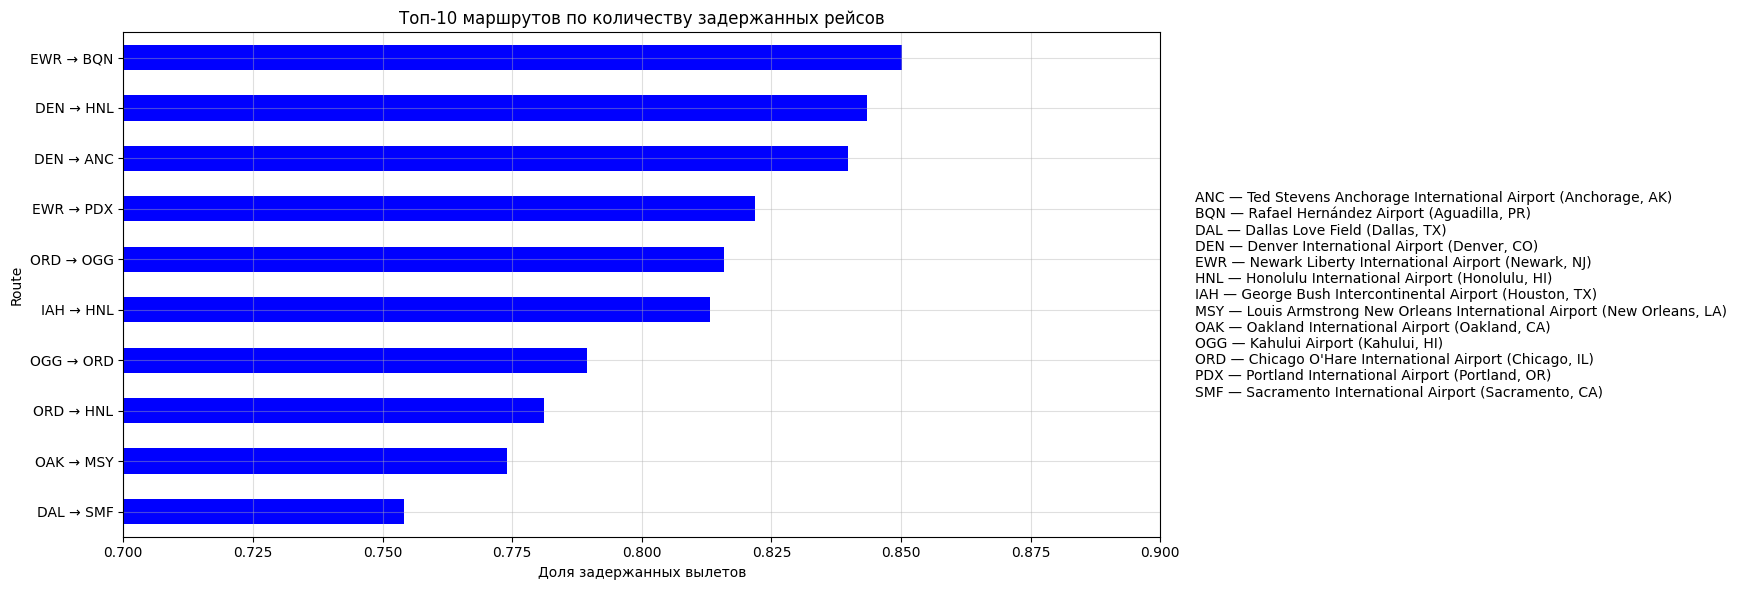

In [32]:
df_not_cancelled["ROUTE"] = df_not_cancelled["ORIGIN_AIRPORT"] + " → " + df_not_cancelled["DESTINATION_AIRPORT"]

route_stats = df_not_cancelled.groupby("ROUTE").agg(
    delay_share=("IS_DELAYED", "mean"),
    flights=("IS_DELAYED", "count")
)
route_stats = route_stats[route_stats["flights"] >= 100]
route_stats = route_stats.sort_values("delay_share", ascending=False)
top10_routes = route_stats.head(10)

plt.figure(figsize=(12,6))
top10_routes["delay_share"].sort_values().plot(kind="barh", color="blue")
plt.title("Топ-10 маршрутов по количеству задержанных рейсов")
plt.xlabel("Доля задержанных вылетов")
plt.ylabel("Route")
plt.xlim(0.7, 0.9)
plt.grid(True, alpha=0.4)

airport_codes = set()
for route in top10_routes.index:
    origin, dest = route.split(" → ")
    airport_codes.add(origin)
    airport_codes.add(dest)

legend_text = "\n".join(
    f"{row.IATA_CODE} — {row.AIRPORT} ({row.CITY}, {row.STATE})"
    for _, row in airports[airports["IATA_CODE"].isin(airport_codes)].iterrows()
)

plt.gcf().text(1, 0.5, legend_text, fontsize=10, va="center")
plt.tight_layout()
plt.show()